In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [6]:
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")

In [7]:
df = orders.merge(items, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(reviews, on="order_id", how="left")
df = df.merge(translation, on="product_category_name", how="left")

In [8]:
df = df[df["order_status"] == "delivered"]

In [9]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["revenue"] = df["price"]

In [10]:
total_revenue = df["revenue"].sum()
aov = df.groupby("order_id")["price"].sum().mean()
df["delivery_time"] = (
    pd.to_datetime(df["order_delivered_customer_date"]) -
    pd.to_datetime(df["order_purchase_timestamp"])).dt.days
avg_delivery = df["delivery_time"].mean()
avg_review = df["review_score"].mean()
print("Total Revenue:", total_revenue)
print("AOV:", aov)
print("Avg Delivery:", avg_delivery)
print("Avg Review:", avg_review)

Total Revenue: 13279836.59
AOV: 137.64626743920894
Avg Delivery: 12.012036235022377
Avg Review: 4.081308572623236


In [21]:
df["month"] = df["order_purchase_timestamp"].dt.to_period("M")
monthly_kpi = df.groupby("month").agg(
    revenue=("revenue", "sum"),
    aov=("price", "mean"),
    delivery=("delivery_time", "mean"),
    review=("review_score", "mean"))
monthly_kpi

,revenue,aov,delivery,review
month,,,,
2016-09,134.97,44.990000,54.000000,1.000000
2016-10,40451.80,127.608202,19.094637,3.913738
2016-12,10.90,10.900000,4.000000,5.000000
2017-01,112573.39,121.832673,12.071429,4.166302
2017-02,235483.40,125.994329,12.590155,4.180204
2017-03,360865.25,123.711090,12.414467,4.132434
2017-04,341209.62,132.405751,14.272798,4.099103
2017-05,492620.44,121.694773,10.898690,4.203538
2017-06,425387.66,120.711595,11.464245,4.190626


In [22]:
category_kpi = df.groupby("product_category_name_english").agg(
    revenue=("revenue", "sum"),
    review=("review_score", "mean"),
    delivery=("delivery_time", "mean")
).reset_index()

In [23]:
top5 = category_kpi.sort_values("revenue", ascending=False).head(5)
bottom5 = category_kpi.sort_values("revenue", ascending=True).head(5)
top5, bottom5

(   product_category_name_english     revenue    review   delivery
 43                 health_beauty  1237439.95  4.190778  11.522219
 70                 watches_gifts  1167246.63  4.071931  12.191410
 7                 bed_bath_table  1037177.69  3.920983  12.344017
 65                sports_leisure   960189.09  4.166430  11.686852
 15         computers_accessories   896243.28  3.984750  12.795770,
    product_category_name_english  revenue    review   delivery
 61         security_and_services   283.29  2.500000  15.000000
 29     fashion_childrens_clothes   519.95  5.000000   8.142857
 11             cds_dvds_musicals   730.00  4.642857  10.357143
 46                home_comfort_2   760.27  3.629630  14.066667
 35                       flowers  1110.04  4.419355  10.696970)

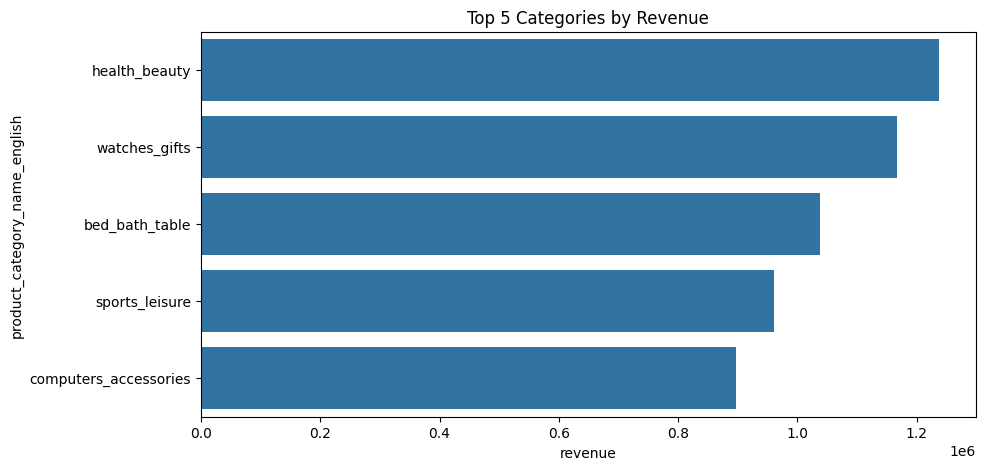

In [24]:
plt.figure(figsize=(10,5))
sns.barplot(data=top5, x="revenue", y="product_category_name_english")
plt.title("Top 5 Categories by Revenue")
plt.show()

In [25]:
top_review = category_kpi.sort_values("review", ascending=False).head(5)
bottom_review = category_kpi.sort_values("review", ascending=True).head(5)
top_review, bottom_review

(   product_category_name_english   revenue    review   delivery
 29     fashion_childrens_clothes    519.95  5.000000   8.142857
 11             cds_dvds_musicals    730.00  4.642857  10.357143
 8         books_general_interest  45302.15  4.512195  11.171642
 9                 books_imported   4418.86  4.508772   7.666667
 22       costruction_tools_tools  15903.95  4.444444  11.631068,
    product_category_name_english    revenue    review   delivery
 61         security_and_services     283.29  2.500000  15.000000
 23           diapers_and_hygiene    1500.79  3.378378  10.243243
 57              office_furniture  269418.10  3.517428  20.397497
 46                home_comfort_2     760.27  3.629630  14.066667
 30         fashion_male_clothing   10452.33  3.758065  12.472000)

In [26]:
seller_kpi = df.groupby("seller_id").agg(
    revenue=("revenue", "sum"),
    orders=("order_id", "nunique"),
    review=("review_score", "mean")
).reset_index()

In [27]:
seller_kpi.sort_values("revenue", ascending=False).head(10)

,seller_id,revenue,orders,review
834,4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,1124,4.139474
982,53243585a1d6dc2643021fd1853d8905,217940.44,348,4.128141
858,4a3ca9315b744ce9f8e9374361493884,199408.32,1772,3.828630
2903,fa1c13f2614d7b5c4749cbc52fecda94,190917.14,578,4.373913
1480,7c67e1448b00f6e969d365cea6b010ab,188063.83,973,3.354197
1504,7e93a43ef30c4f03f38b393420bc753a,165981.49,319,4.364486
2543,da8622b14eb17ae2831f4ac5b9dab84a,162303.67,1311,4.075399
1450,7a67c85e85bb2ce8582c35f2203ad736,140238.65,1145,4.268462
188,1025f0e2d44d7041d6cf58b6550e0bfa,139720.16,910,3.867792
1758,955fee9216a65b617aa5c0531780ce60,131906.71,1261,4.089481


In [28]:
corr = df["delivery_time"].corr(df["review_score"])
corr

np.float64(-0.3040128606410494)

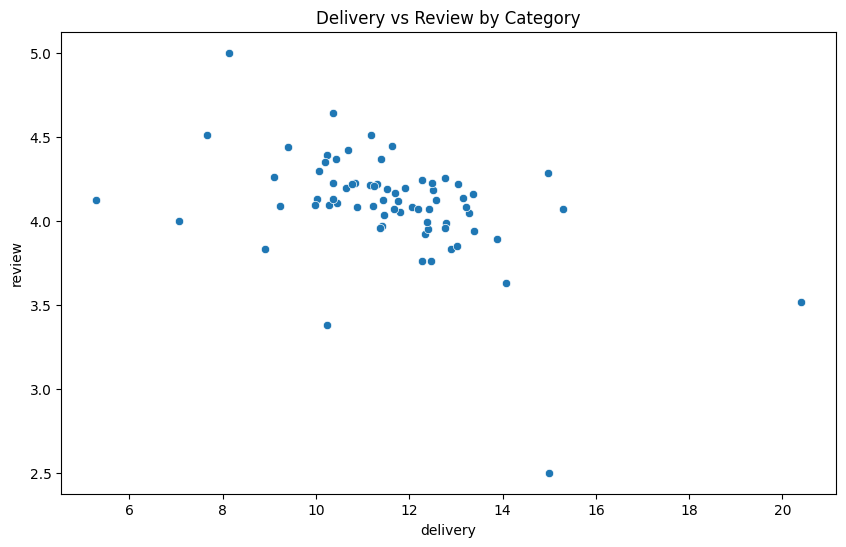

In [29]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=category_kpi, x="delivery", y="review")
plt.title("Delivery vs Review by Category")
plt.show()

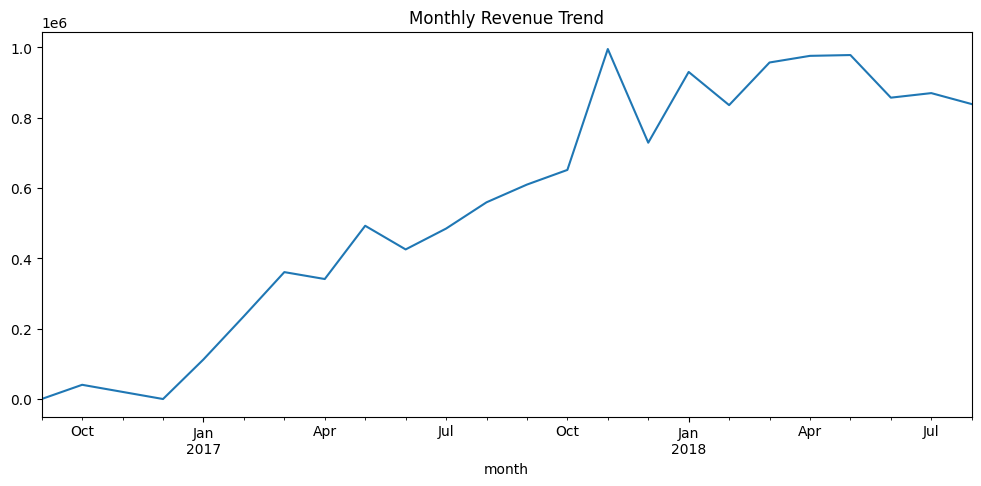

In [30]:
monthly_kpi["revenue"].plot(figsize=(12,5))
plt.title("Monthly Revenue Trend")
plt.show()

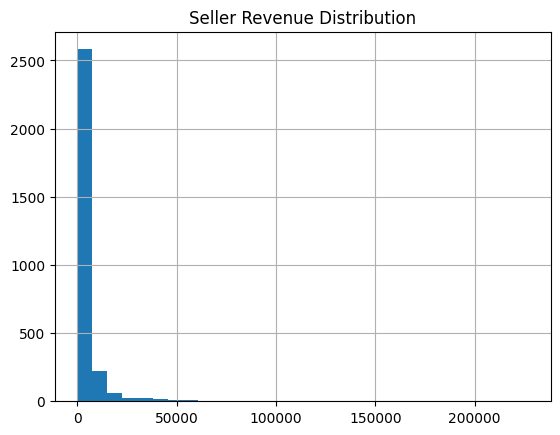

In [31]:
seller_kpi["revenue"].hist(bins=30)
plt.title("Seller Revenue Distribution")
plt.show()

In [ ]:
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_kpi = df.groupby('month').agg(
    revenue=('revenue', 'sum'),
    aov=('revenue', lambda x: x.sum() / x.nunique()),
    avg_review=('review_score', 'mean'),
    avg_delivery_time=('delivery_time', 'mean')
).reset_index() #bonus
monthly_kpi

,month,revenue,aov,avg_review,avg_delivery_time
0,2016-09,134.97,134.970000,1.000000,54.000000
1,2016-10,40451.80,275.182313,3.913738,19.094637
2,2016-12,10.90,10.900000,5.000000,4.000000
3,2017-01,112573.39,351.791844,4.166302,12.071429
4,2017-02,235483.40,429.714234,4.180204,12.590155
5,2017-03,360865.25,511.865603,4.132434,12.414467
6,2017-04,341209.62,493.077486,4.099103,14.272798
7,2017-05,492620.44,569.503399,4.203538,10.898690
8,2017-06,425387.66,551.020285,4.190626,11.464245
9,2017-07,484637.74,539.685679,4.182558,10.978700


In [38]:
category_kpi = df.groupby('product_category_name_english').agg(
    revenue=('revenue', 'sum'),
    review_score=('review_score', 'mean'),
    delivery_time=('delivery_time', 'mean')
).reset_index()
# orta deyerler
avg_delivery = category_kpi['delivery_time'].mean()
avg_review = category_kpi['review_score'].mean()
# risk serti
category_kpi['risk_flag'] = (
    (category_kpi['delivery_time'] > avg_delivery) &
    (category_kpi['review_score'] < avg_review))
category_kpi

,product_category_name_english,revenue,review_score,delivery_time,risk_flag
0,agro_industry_and_commerce,70566.10,4.087379,11.223301,False
1,air_conditioning,53323.56,4.052817,11.792388,True
2,art,23657.30,4.082051,10.873096,False
3,arts_and_craftmanship,1814.01,4.125000,5.291667,False
4,audio,50620.50,3.830084,12.892562,True
...,...,...,...,...,...
66,stationery,224145.67,4.244002,12.282538,False
67,tablets_printing_image,7528.41,4.123457,12.578313,False
68,telephony,310004.11,3.995009,12.385205,True
69,toys,472109.78,4.207886,11.241516,False


In [39]:
risk_categories = category_kpi[category_kpi['risk_flag'] == True]
risk_categories

,product_category_name_english,revenue,review_score,delivery_time,risk_flag
1,air_conditioning,53323.56,4.052817,11.792388,True
4,audio,50620.50,3.830084,12.892562,True
6,baby,400774.42,4.079205,12.062542,True
7,bed_bath_table,1037177.69,3.920983,12.344017,True
12,christmas_supplies,8737.84,4.069930,15.300000,True
15,computers_accessories,896243.28,3.984750,12.795770,True
26,electronics,155173.83,4.067503,12.426374,True
30,fashion_male_clothing,10452.33,3.758065,12.472000,True
33,fashion_underwear_beach,9305.95,4.047619,13.275591,True
34,fixed_telephony,55355.20,3.758893,12.269531,True
